<a href="https://colab.research.google.com/github/jromeo3415/BERT-adapt-to-NER/blob/main/ADL_final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Chosen Project**: Named Entity Recognition (NER)

Loading conll2003 dataset

In [ ]:
from datasets import load_dataset

dataset = load_dataset("conll2003", revision="refs/convert/parquet")
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 14041
    })
    validation: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3250
    })
    test: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3453
    })
})


Converting to dataframes and exploring dataset

In [ ]:
import pandas as pd

#converting to dataframe
train_df = dataset['train'].to_pandas()
validation_df = dataset['validation'].to_pandas()
test_df = dataset['test'].to_pandas()

#defining ner tags dict
id_to_label = {0: 'O', 1: 'B-PER', 2: 'I-PER', 3: 'B-ORG', 4: 'I-ORG', 5: 'B-LOC', 6: 'I-LOC', 7: 'B-MISC', 8: 'I-MISC'}

#printing without row or column truncation
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
  print(f"Train columns: {train_df.columns}")
  print(f"Number of training rows: {train_df['id'].count()}")

  print("\nFirst sentence's contents and corresponding NER tags:")
  print(train_df['tokens'][0])
  for tag in train_df['ner_tags'][0]:
    print(id_to_label[tag], end=", ")

Train columns: Index(['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'], dtype='object')
Number of training rows: 14041

First sentence's contents and corresponding NER tags:
['EU' 'rejects' 'German' 'call' 'to' 'boycott' 'British' 'lamb' '.']
B-ORG, O, B-MISC, O, O, O, B-MISC, O, O, 

**Defining BERT tokenizer and label alignment**

In [ ]:
# applys BERT word level tokenization to each sentence and returns tokens
def tokenize(tokens):

  #applying tokenizer
  enc = tokenizer(
      tokens["tokens"],
      is_split_into_words=True,
      return_offsets_mapping=True,
      truncation=True
  )

  aligned_labels = []

  for i in range(len(tokens["tokens"])):
    label_id = []
    previous_id = None
    word_ids = enc.word_ids(batch_index=i)

    for word_id in word_ids:
      if word_id == None:
        label_id.append(-100)
      elif word_id != previous_id:
        label_id.append(tokens["ner_tags"][i][word_id])
      else:
        label_id.append(-100)

      previous_id = word_id

    aligned_labels.append(label_id)

  enc["labels"] = aligned_labels
  return enc

**Applying tokenizaiton then label alignment for entire dataset**

In [ ]:
from transformers import BertTokenizerFast

tokenizer = BertTokenizerFast.from_pretrained("bert-base-cased")
dataset = dataset.map(tokenize, batched=True)

Map:   0%|          | 0/3250 [00:00<?, ? examples/s]

**Creating Trainer**

In [ ]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./ner_model",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    num_train_epochs=10,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_strategy="epoch"
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


**Training model**

In [ ]:
from transformers import BertForTokenClassification, DataCollatorForTokenClassification
import torch

data_collator = DataCollatorForTokenClassification(tokenizer)

model = BertForTokenClassification.from_pretrained(
    "bert-base-cased",
    num_labels=len(id_to_label)
)

#ensuring tensors are all on same device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

#defining metrics for evaluation
from seqeval.metrics import classification_report, f1_score, precision_score, recall_score

label_to_id = {'O': 0, 'B-PER': 1, 'I-PER': 2, 'B-ORG': 3, 'I-ORG': 4, 'B-LOC': 5, 'I-LOC': 6, 'B-MISC': 7, 'I-MISC': 8}
id_to_label = {v: k for k, v in label_to_id.items()}

def compute_metrics(p):

    predictions, labels = p
    predictions = predictions.argmax(axis=-1)

    true_labels = []
    true_preds = []

    for pred, lab in zip(predictions, labels):

        curr_preds = []
        curr_labels = []

        for p_, l_ in zip(pred, lab):
            if l_ != -100:
                curr_preds.append(id_to_label[p_])
                curr_labels.append(id_to_label[l_])

        true_preds.append(curr_preds)
        true_labels.append(curr_labels)

    return {
        "precision": precision_score(true_labels, true_preds),
        "recall": recall_score(true_labels, true_preds),
        "f1": f1_score(true_labels, true_preds)
    }

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer.train()
logs = trainer.state.log_history

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized beca

Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,0.218145,0.046876,0.907319,0.924268,0.915715
2,0.037910,0.040166,0.930690,0.940088,0.935365
3,0.022670,0.035520,0.941893,0.949344,0.945604
4,0.015444,0.035800,0.935559,0.947997,0.941737
5,0.011162,0.037513,0.938650,0.952710,0.945628
6,0.008273,0.038673,0.941147,0.952710,0.946893
7,0.006414,0.041307,0.941343,0.950690,0.945993
8,0.005548,0.039105,0.943305,0.952036,0.947651
9,0.004446,0.040130,0.944009,0.953383,0.948673
10,0.004086,0.040655,0.942852,0.952373,0.947589


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

**Evaluation**

In [ ]:
# predicts named fields for given sentence. returns labels for each token in list
def predict_sentence(sentence):

    model.eval()

    inputs = tokenizer(sentence, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits
    preds = torch.argmax(logits, dim=-1)[0].cpu().numpy()

    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

    results = []
    for token, pred in zip(tokens, preds):
        results.append((token, id_to_label[pred]))

    return results


print("Labels for sample sentence:")
print(predict_sentence("The Google executives are hiring 2000 new employees in Tampa, Florida."))
print(predict_sentence("Barack Obama was the president of the United States."))
print(predict_sentence("Apple released the new iPhone in California."))

Labels for sample sentence:
[('[CLS]', 'O'), ('The', 'O'), ('Google', 'B-ORG'), ('executives', 'O'), ('are', 'O'), ('hiring', 'O'), ('2000', 'O'), ('new', 'O'), ('employees', 'O'), ('in', 'O'), ('Tampa', 'B-LOC'), (',', 'O'), ('Florida', 'B-LOC'), ('.', 'O'), ('[SEP]', 'O')]
[('[CLS]', 'O'), ('Barack', 'B-PER'), ('Obama', 'I-PER'), ('was', 'O'), ('the', 'O'), ('president', 'O'), ('of', 'O'), ('the', 'O'), ('United', 'B-LOC'), ('States', 'I-LOC'), ('.', 'O'), ('[SEP]', 'O')]
[('[CLS]', 'O'), ('Apple', 'B-ORG'), ('released', 'O'), ('the', 'O'), ('new', 'O'), ('iPhone', 'B-MISC'), ('in', 'O'), ('California', 'B-LOC'), ('.', 'O'), ('[SEP]', 'O')]


Plotting metrics

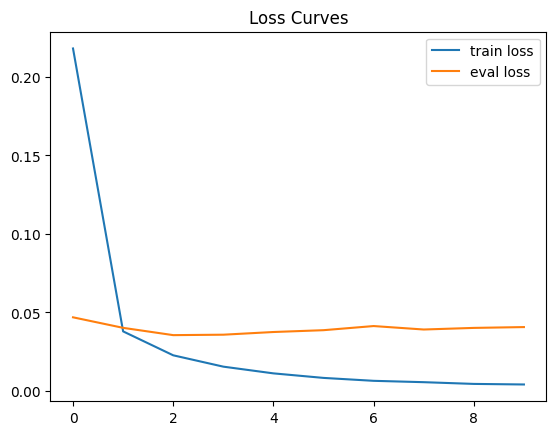

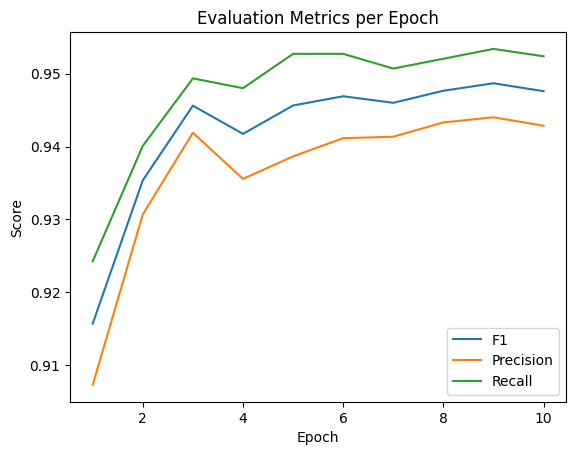

In [ ]:

# plotting loss curves
import matplotlib.pyplot as plt

train_loss = [x["loss"] for x in logs if "loss" in x]
eval_loss = [x["eval_loss"] for x in logs if "eval_loss" in x]

plt.plot(train_loss, label="train loss")
plt.plot(eval_loss, label="eval loss")
plt.legend()
plt.title("Loss Curves")
plt.show()

eval_f1 = [x["eval_f1"] for x in logs if "eval_f1" in x]
eval_precision = [x["eval_precision"] for x in logs if "eval_precision" in x]
eval_recall = [x["eval_recall"] for x in logs if "eval_recall" in x]
epochs = [x["epoch"] for x in logs if "eval_f1" in x]

plt.plot(epochs, eval_f1, label="F1")
plt.plot(epochs, eval_precision, label="Precision")
plt.plot(epochs, eval_recall, label="Recall")

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Evaluation Metrics per Epoch")
plt.legend()
plt.show()